In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
student=pd.read_csv('student.csv')

# What is the total number of students and gender distribution?

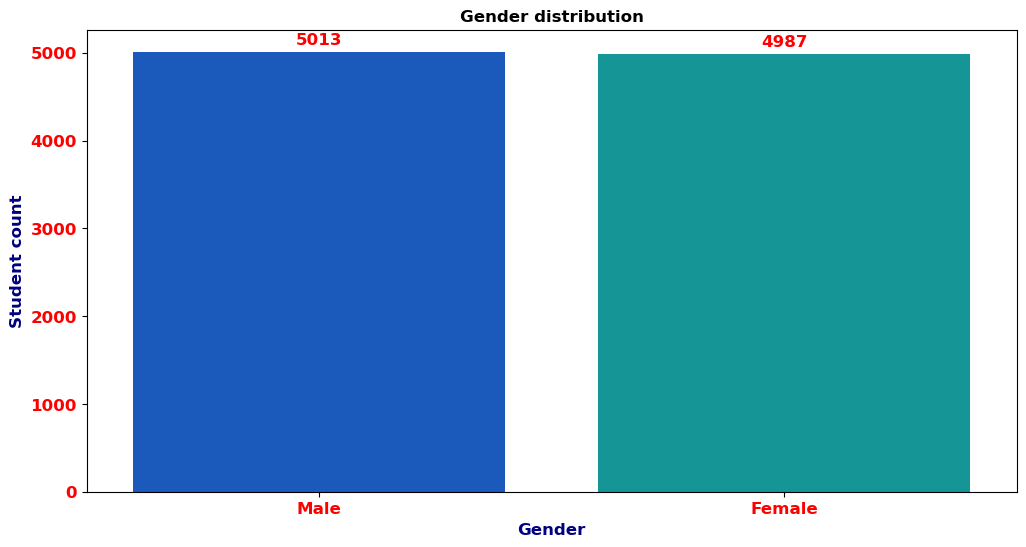

In [23]:
distribution=student.groupby('gender')['student_id'].count().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,6))
ax=sns.barplot(data=distribution,x='gender',y='student_id',palette='winter',hue='gender')
plt.title('Gender distribution',color='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,padding=3,color='red',fontweight='bold',fontsize=12)
plt.xlabel('Gender',color='navy',fontweight='bold',fontsize=12)
plt.ylabel('Student count',color='navy',fontweight='bold',fontsize=12)
plt.xticks(color='red',fontweight='bold',fontsize=12)
plt.yticks(color='red',fontweight='bold',fontsize=12)
plt.show()

# What are the average study hours, attendance, and overall score?


In [14]:
student.agg({
    'study_hours_per_day':'mean',
    'attendance_percentage':'mean',
    'overall_score':'mean'
}).reset_index().round().rename(columns={0:'Average'})

,index,Average
0,study_hours_per_day,5.0
1,attendance_percentage,70.0
2,overall_score,64.0


 # Which grade appears most frequently?

In [20]:
student['grade'].value_counts().idxmax()

'C'

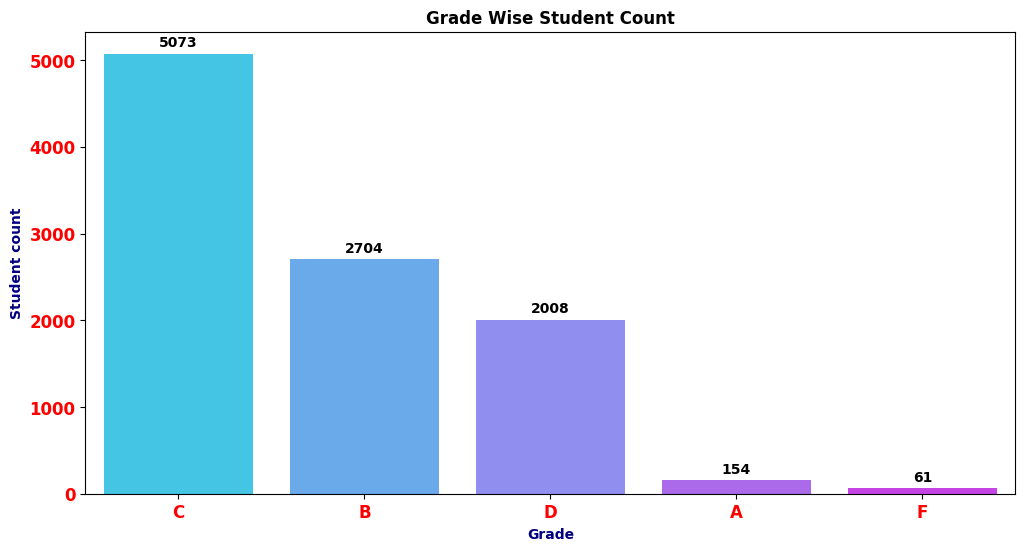

In [39]:
grade=student.groupby('grade')['student_id'].count().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,6))
ax=sns.barplot(data=grade,x='grade',y='student_id',palette='cool',hue='grade')
for container in ax.containers:
    ax.bar_label(container,padding=3,)
plt.title('Grade Wise Student Count',fontweight='bold',color='black')
plt.xlabel('Grade',fontweight='bold',color='navy')
plt.ylabel('Student count',fontweight='bold',color='navy')
plt.xticks(color='red',fontweight='bold',fontsize=12)
plt.yticks(color='red',fontweight='bold',fontsize=12)
plt.show()


# Does study_hours_per_day impact overall_score?



In [56]:
impacet=student['study_hours_per_day'].corr(student['overall_score']).round(4)
print('No Impacet study hours and over score:',impacet)

No Impacet study hours and over score: -0.0037


# Do students with higher attendance perform better?


In [55]:
impact=student['attendance_percentage'].corr(student['overall_score']).round(3)
print('Correlation between attendance and overall score:', impact)

Correlation between attendance and overall score: 0.149


# Which component (assignment, midterm, final) impacts overall_score the most?

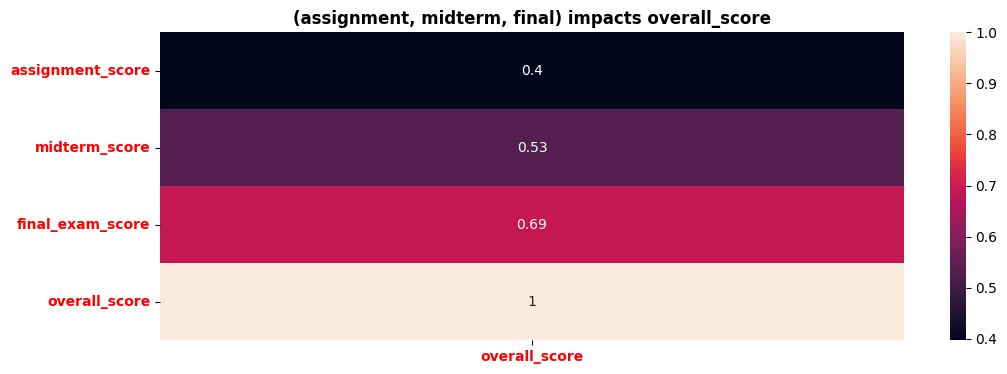

In [19]:
corr=student[['assignment_score', 'midterm_score', 'final_exam_score', 'overall_score']].corr()[['overall_score']]
plt.figure(figsize=(12,4))
sns.heatmap(corr,annot=True)
plt.title('(assignment, midterm, final) impacts overall_score',fontweight='bold',color='black')
plt.xticks(color='red',fontweight='bold')
plt.yticks(color='red',fontweight='bold')
plt.show()

# Does sleep_hours affect student performance?



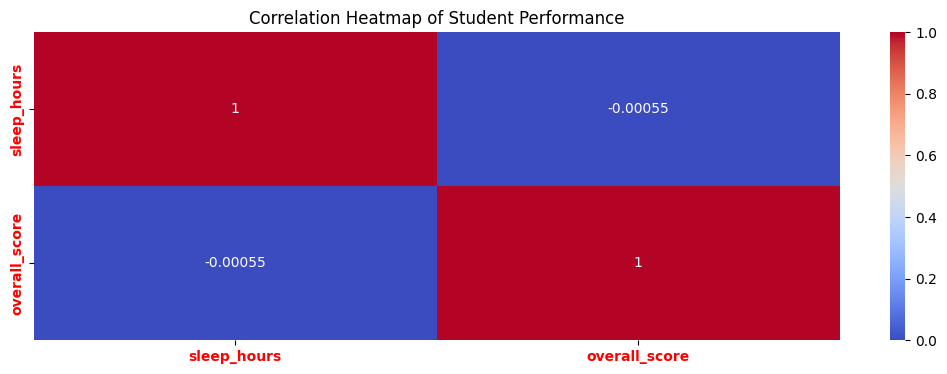

In [39]:
sleep=student[['sleep_hours','overall_score']].corr()

plt.figure(figsize=(13, 4))
sns.heatmap(sleep, annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap of Student Performance')
plt.xticks(color='red',fontweight='bold')
plt.yticks(color='red',fontweight='bold')
plt.show()

# Do students who take extra_classes perform better?


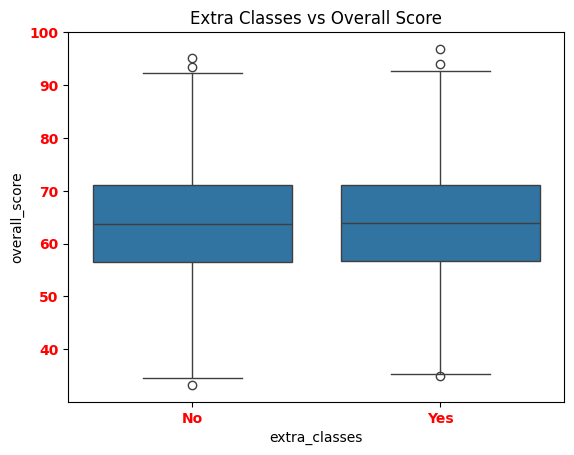

In [51]:
student.groupby('extra_classes')['overall_score'].mean()
sns.boxplot(x='extra_classes', y='overall_score', data=student)
plt.title('Extra Classes vs Overall Score')
plt.xticks(color='red',fontweight='bold')
plt.yticks(color='red',fontweight='bold')
plt.show()

In [50]:
student['extra_classes_numerice']=student['extra_classes'].map({'Yes':1,'No':0})
relation=student['extra_classes_numerice'].corr(student['overall_score'])
print('No relation extra class and overall score :',relation)

No relation extra class and overall score : 0.00621867117821394


# Does internet_access improve performance?

In [4]:
student.groupby('internet_access').agg({
    'overall_score':'mean',
    'final_exam_score':'mean',
    'midterm_score':'mean'
}).reset_index()

,internet_access,overall_score,final_exam_score,midterm_score
0,No,63.525771,64.312936,61.790755
1,Yes,64.120773,65.630958,62.841561


# Which students achieve high performance with low study hours?

In [17]:
(student[(student['study_hours_per_day']<student['study_hours_per_day'].mean()) &
    (student['overall_score']>student['overall_score'].mean())])

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade,variance
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C,1280.432133
10,100010,Male,2.49,44.05,93.34,69.26,84.16,72.09,Yes,Yes,Bachelor,4.05,77.0530,B,147.688133
15,100015,Male,2.91,90.93,71.05,82.20,63.36,82.42,Yes,No,Bachelor,8.10,74.2710,B,89.734033
27,100027,Female,1.48,79.26,93.74,47.37,74.58,88.79,Yes,No,Bachelor,5.14,73.4985,B,542.944433
29,100029,Female,2.09,61.98,49.58,98.76,98.00,61.98,No,Yes,Master,6.87,81.3020,B,793.957733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,109985,Female,5.07,89.59,50.47,75.91,68.88,60.16,Yes,No,High School,4.18,68.1545,C,172.590433
9992,109992,Female,3.14,94.95,52.03,97.33,72.89,67.64,Yes,No,Bachelor,5.53,76.5090,B,514.090533
9996,109996,Male,2.60,83.62,62.45,48.96,81.40,45.11,Yes,Yes,Bachelor,4.21,66.0930,C,265.572700
9997,109997,Female,1.46,95.40,67.08,51.51,87.58,65.49,Yes,No,Bachelor,4.72,73.0355,B,327.286633


# Who are the most consistent performers (low variance)?

In [10]:
student['variance'] = student[['assignment_score', 'midterm_score', 'final_exam_score']].var(axis=1)
student[['student_id','variance']].sort_values(by='variance',ascending=False).head(10)

,student_id,variance
4760,104760,1717.000833
3986,103986,1646.043233
9904,109904,1638.321233
7018,107018,1635.503033
6386,106386,1591.578300
251,100251,1560.539233
4844,104844,1558.963233
4802,104802,1556.143900
7437,107437,1548.398700
5996,105996,1535.031100


# Which students are at risk (low attendance + low score)?



In [35]:
risk=(student[(student['attendance_percentage']<student['attendance_percentage'].mean()) 
    &(student['overall_score']<student['overall_score'].mean())])


In [40]:
risk[['student_id','attendance_percentage','overall_score']]

,student_id,attendance_percentage,overall_score
0,100000,69.98,52.3480
5,100005,53.16,59.3525
8,100008,70.24,53.7460
9,100009,52.19,60.1865
11,100011,50.29,62.9825
...,...,...,...
9983,109983,70.14,53.8845
9984,109984,60.08,57.3115
9987,109987,63.62,63.6260
9993,109993,51.37,50.8125


# Identify weak students based on performance


In [76]:
weak_student=(student[(student['study_hours_per_day']<student['study_hours_per_day'].mean()) &
    (student['attendance_percentage']<student['attendance_percentage'].mean()) &
    (student['overall_score']<student['overall_score'].mean())])

weak_student[['student_id','study_hours_per_day','attendance_percentage','attendance_percentage']]

,student_id,study_hours_per_day,attendance_percentage,attendance_percentage
0,100000,4.54,69.98,69.98
5,100005,1.79,53.16,53.16
8,100008,2.64,70.24,70.24
9,100009,4.87,52.19,52.19
26,100026,3.33,58.25,58.25
...,...,...,...,...
9968,109968,4.70,62.57,62.57
9973,109973,2.47,43.86,43.86
9981,109981,4.10,57.22,57.22
9983,109983,4.37,70.14,70.14


In [20]:
student['performance_score'] = (
    student['overall_score'] * 0.5 +
    student['attendance_percentage'] * 0.3 +
    student['study_hours_per_day'] * 10
)

weak_students = student[student['performance_score'] < student['performance_score'].quantile(0.25)]

weak_students

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade,performance_score
5,100005,Female,1.79,53.16,33.61,54.26,79.79,58.23,No,No,Bachelor,5.43,59.3525,C,63.52425
8,100008,Male,2.64,70.24,53.65,56.28,40.72,76.70,No,No,Bachelor,5.12,53.7460,D,74.34500
10,100010,Male,2.49,44.05,93.34,69.26,84.16,72.09,Yes,Yes,Bachelor,4.05,77.0530,B,76.64150
14,100014,Female,2.77,92.04,33.79,37.51,54.20,39.65,No,No,High School,8.64,48.2745,D,79.44925
16,100016,Female,1.37,70.69,92.11,41.44,51.68,90.20,No,No,PhD,7.88,62.9590,C,66.38650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9973,109973,Female,2.47,43.86,62.23,28.71,41.23,15.17,Yes,No,High School,8.75,39.9570,F,57.83650
9974,109974,Male,1.38,93.24,76.19,42.97,36.89,33.09,Yes,No,Bachelor,5.27,51.5250,D,67.53450
9977,109977,Female,2.85,73.78,61.93,73.38,38.56,25.58,Yes,No,High School,7.19,54.1630,D,77.71550
9996,109996,Male,2.60,83.62,62.45,48.96,81.40,45.11,Yes,Yes,Bachelor,4.21,66.0930,C,84.13250


# Does parent_education affect student performance?



In [43]:
parent=student.groupby('parent_education').agg({
    'student_id':'count',
    'study_hours_per_day':'mean',
    'final_exam_score':'mean',
    'sleep_hours':'mean',
    'overall_score':'mean'
}).reset_index()
parent

,parent_education,student_id,study_hours_per_day,final_exam_score,sleep_hours,overall_score
0,Bachelor,2527,5.381104,65.006110,6.543174,64.008239
1,High School,2528,5.507520,65.094363,6.535684,63.753196
2,Master,2487,5.515501,65.167069,6.470326,63.920976
3,PhD,2458,5.467917,64.646208,6.469951,63.621093


# Is there any performance difference based on gender?



In [34]:
df=student.groupby('gender').agg({
    'student_id':'count',
    'study_hours_per_day':'mean',
    'final_exam_score':'mean',
    'sleep_hours':'mean',
    'overall_score':'mean'
})
print(df)

        student_id  study_hours_per_day  final_exam_score  sleep_hours  \
gender                                                                   
Female        4987             5.480193         65.000545     6.511137   
Male          5013             5.455522         64.959535     6.499224   

        overall_score  
gender                 
Female      63.830053  
Male        63.823766  


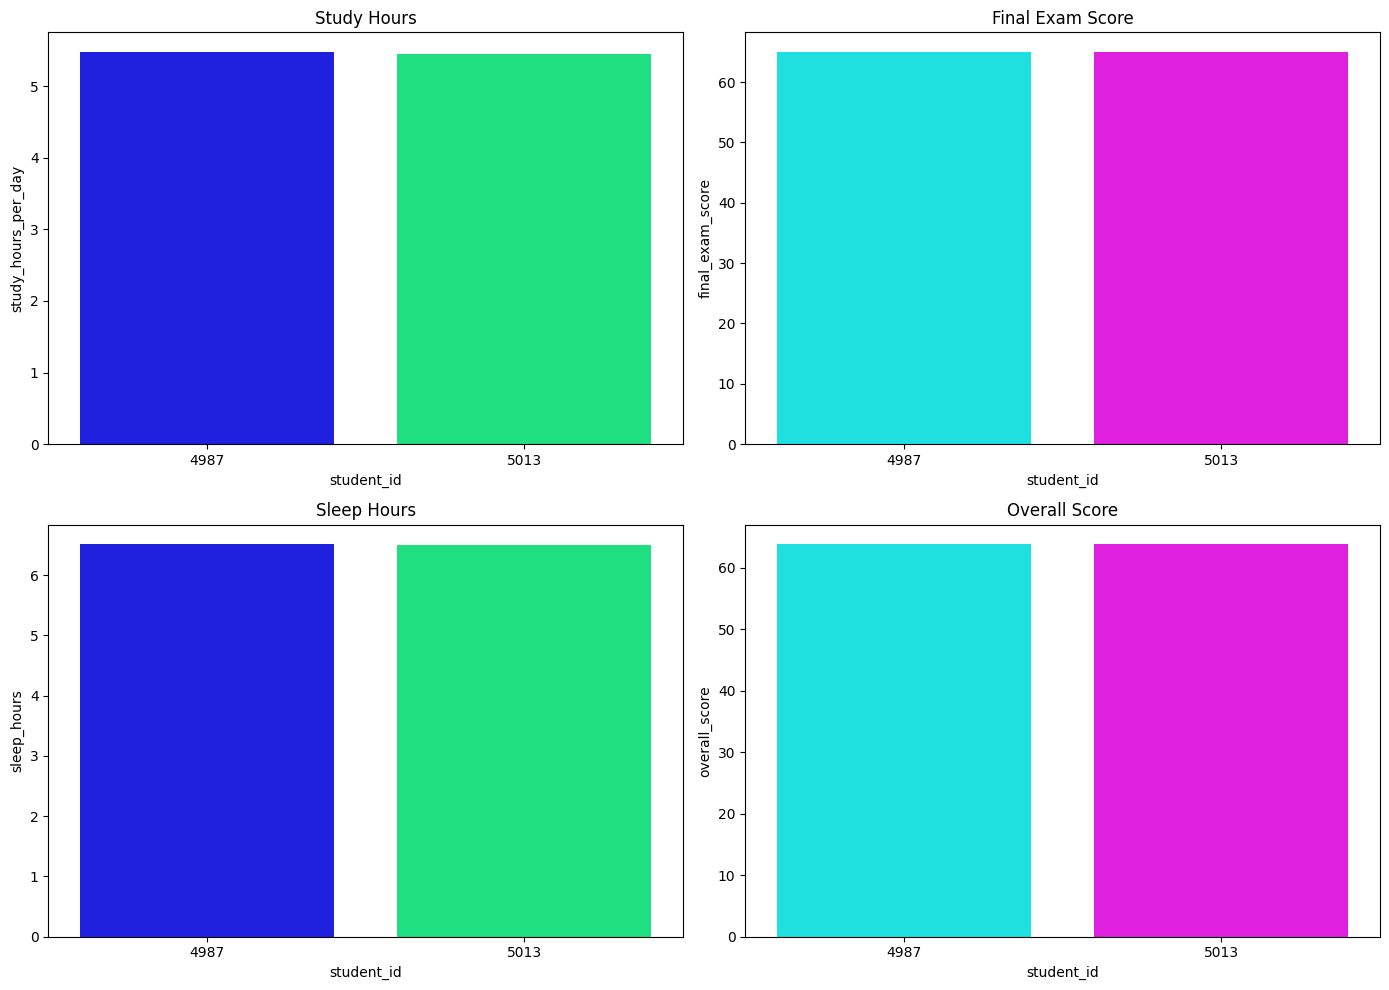

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x='student_id', y='study_hours_per_day', data=df, ax=axes[0,0],palette='winter',hue='student_id',legend=False)
axes[0,0].set_title('Study Hours')

sns.barplot(x='student_id', y='final_exam_score', data=df, ax=axes[0,1],palette='cool',hue='student_id',legend=False)
axes[0,1].set_title('Final Exam Score')

sns.barplot(x='student_id', y='sleep_hours', data=df, ax=axes[1,0],palette='winter',hue='student_id',legend=False)
axes[1,0].set_title('Sleep Hours')

sns.barplot(x='student_id', y='overall_score', data=df, ax=axes[1,1],palette='cool',hue='student_id',legend=False)
axes[1,1].set_title('Overall Score')

plt.tight_layout()
plt.show()

# Which factor improvement leads to maximum score increase?



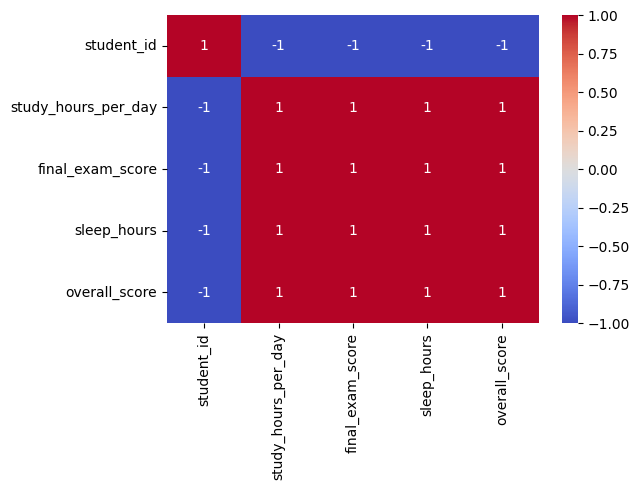

In [45]:
df[['study_hours_per_day', 'final_exam_score', 'sleep_hours', 'overall_score']].corr()['overall_score']

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [46]:
corr = df.corr()['overall_score'].drop('overall_score')

print(corr.sort_values(ascending=False))

study_hours_per_day    1.0
final_exam_score       1.0
sleep_hours            1.0
student_id            -1.0
Name: overall_score, dtype: float64


#  Who are the top students eligible for scholarship

In [62]:
top_student=student[(student['overall_score']>=90) &(student['attendance_percentage']>90)]
top_student[['student_id','overall_score','attendance_percentage']]

,student_id,overall_score,attendance_percentage
12,100012,92.3830,99.06
2135,102135,91.6830,97.13
4349,104349,90.3465,99.83
5665,105665,90.0455,90.92
5745,105745,96.8795,98.96
7374,107374,94.0470,91.41
7472,107472,91.9345,91.97
7667,107667,91.8645,92.88
8453,108453,95.2065,98.61
8563,108563,91.7020,94.83


#  Detect outliers in student performance

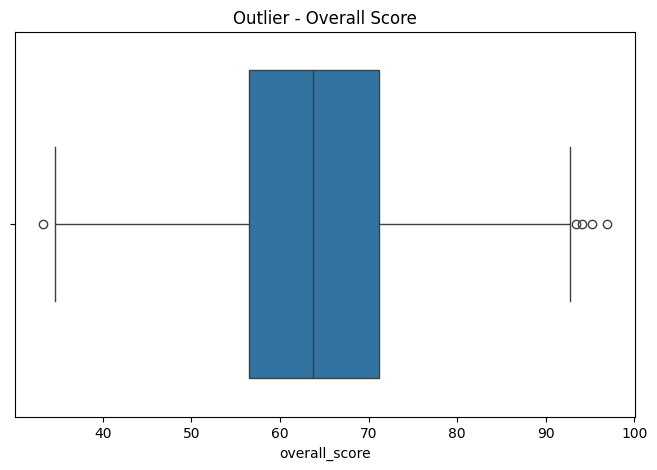

In [79]:
plt.figure(figsize=(8,5))
sns.boxplot(x=student['overall_score'])
plt.title("Outlier - Overall Score")
plt.show()

In [69]:
q1=student['overall_score'].quantile(0.25)
q3=student['overall_score'].quantile(0.75)

q1,q3

(np.float64(56.528125), np.float64(71.163125))

In [70]:
IQR=q3 - q1
IQR

np.float64(14.634999999999991)

In [71]:
min_range=q1 - (1.5*IQR)
max_range=q3 + (1.5*IQR)
min_range,max_range

(np.float64(34.57562500000002), np.float64(93.11562499999998))

In [ ]:
new_out=student[student['overall_score']<=max_range]

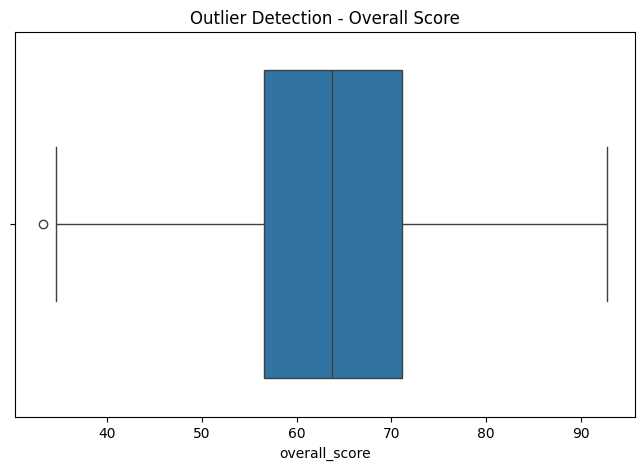

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x=new_out['overall_score'])
plt.title("reOutlier Detection - Overall Score")
plt.show()